# MIMIC Sepsis Shock Prediction with Trajectory Features
Feature configurations: baseline, summary stats, trajectory probs, and combinations.

## Setup

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import os
import sys
warnings.filterwarnings('ignore')

from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier

sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../../..'))
from notebook_utils import biomarker_summary_stats
from traj_features.backends.bootstrap import BootstrapTrajPS, BootstrapConfig
from traj_features.backends.bayes.classify import pos_flags_from_traj, flags_from_traj

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('✓ Imports successful')

✓ Imports successful


## Load Data

In [2]:
pred_with_probs_path = '../../../results/mimic/sepsis/sepsis_prediction_dataset_with_probs.csv'
outcome_path = '../../../results/mimic/sepsis/septic_shock_outcomes.csv'
lactate_path = '../../../results/mimic/sepsis/lactate_timeseries.csv'
wbc_path = '../../../results/mimic/sepsis/wbc_timeseries.csv'
platelet_path = '../../../results/mimic/sepsis/platelet_timeseries.csv'

df = pd.read_csv(pred_with_probs_path)
outcomes = pd.read_csv(outcome_path)
lactate_ts = pd.read_csv(lactate_path)
wbc_ts = pd.read_csv(wbc_path)
platelet_ts = pd.read_csv(platelet_path)

print(f'✓ Loaded prediction dataset with probs: {len(df):,} rows')
print(f'✓ Outcomes: {len(outcomes):,} rows')
print(f'✓ Lactate TS: {len(lactate_ts):,} rows')
print(f'✓ WBC TS: {len(wbc_ts):,} rows')
print(f'✓ Platelet TS: {len(platelet_ts):,} rows')

df = df.merge(outcomes[['hadm_id', 'time_day', 'target_septic_shock']], on=['hadm_id', 'time_day'], how='left')
df = df[df['target_septic_shock'].notna()].copy()
df['target_septic_shock'] = df['target_septic_shock'].astype(int)

traj_cols = [c for c in df.columns if c.startswith('prob_') or c.endswith('_stable') or c.endswith('_gradual') or c.endswith('_rapid') or 'worsening' in c or 'improving' in c]

print(f'Final dataset rows: {len(df):,}')
print(f'Outcome rate: {df["target_septic_shock"].mean():.1%}')
print(f'Trajectory columns: {len(traj_cols)}')

✓ Loaded prediction dataset with probs: 73,921 rows
✓ Outcomes: 12,435 rows
✓ Lactate TS: 45,751 rows
✓ WBC TS: 93,436 rows
✓ Platelet TS: 97,741 rows
Final dataset rows: 12,435
Outcome rate: 9.7%
Trajectory columns: 9


In [ ]:
# Bootstrap trajectory probabilities (cached)
bootstrap_dir = '../../../results/mimic/sepsis'
os.makedirs(bootstrap_dir, exist_ok=True)

BOOTSTRAP_N = 200

def _load_or_compute_bootstrap(ts_df, biomarker, value_col, cfg, output_name):
    output_path = os.path.join(bootstrap_dir, output_name)
    if os.path.exists(output_path):
        boot_df = pd.read_csv(output_path)
    else:
        traj_input = ts_df[['hadm_id', 'time_days', 'time_day', value_col]].copy()
        traj_input = traj_input.rename(columns={'hadm_id': 'patientid', value_col: 'lab_value'})
        traj_input = traj_input.dropna(subset=['lab_value']).sort_values(by=['patientid', 'time_days'])

        model = BootstrapTrajPS(BootstrapConfig(
            window_years=cfg['window_days'],
            n_bootstrap=cfg.get('n_bootstrap', BOOTSTRAP_N),
            smoothing=None,
            min_points_per_window=4,
            grid_freq=2,
            flat_thr=cfg['flat_thr'],
            decline_thr=cfg['decline_thr'],
            nonlinear_gap=cfg['nonlinear_gap'],
            pids='patientid',
            values='lab_value',
            time_col='time_days',
            windowing_col='time_day',
            n_jobs=-1,
            traj_types=cfg['traj_types'],
            class_func=cfg['class_func'],
            label_map=cfg['label_map'],
            progressbar=False
        ))
        boot_df = model.embed(traj_input)
        boot_df = boot_df.rename(columns={'patientid': 'hadm_id'})
        boot_df.to_csv(output_path, index=False)

    if 'patientid' in boot_df.columns:
        boot_df = boot_df.rename(columns={'patientid': 'hadm_id'})

    rename_map = {
        f"trajtype_{cfg['traj_types'][0]}_prob": f"{biomarker}_stable_boot",
        f"trajtype_{cfg['traj_types'][1]}_prob": f"{biomarker}_gradual_boot",
        f"trajtype_{cfg['traj_types'][2]}_prob": f"{biomarker}_rapid_boot",
    }
    for src in rename_map:
        if src not in boot_df.columns:
            boot_df[src] = np.nan
    boot_df = boot_df.rename(columns=rename_map)
    return boot_df[['hadm_id', 'time_day'] + list(rename_map.values())]

bootstrap_configs = {
    'lactate': {
        'value_col': 'lactate',
        'flat_thr': 0.1,
        'decline_thr': 0.3,
        'nonlinear_gap': 0.5,
        'class_func': pos_flags_from_traj,
        'traj_types': ('stable', 'gradual_increase', 'rapid_increase'),
        'label_map': {'nonprogression': 'stable', 'linear': 'gradual_increase', 'nonlinear': 'rapid_increase'},
        'window_days': 3.0,
    },
    'wbc': {
        'value_col': 'wbc',
        'flat_thr': 1.0,
        'decline_thr': 3.0,
        'nonlinear_gap': 2.0,
        'class_func': pos_flags_from_traj,
        'traj_types': ('stable', 'gradual_increase', 'rapid_increase'),
        'label_map': {'nonprogression': 'stable', 'linear': 'gradual_increase', 'nonlinear': 'rapid_increase'},
        'window_days': 3.0,
    },
    'platelet': {
        'value_col': 'platelet',
        'flat_thr': -20.0,
        'decline_thr': -50.0,
        'nonlinear_gap': 30.0,
        'class_func': flags_from_traj,
        'traj_types': ('stable', 'gradual_decline', 'rapid_decline'),
        'label_map': {'nonprogression': 'stable', 'linear': 'gradual_decline', 'nonlinear': 'rapid_decline'},
        'window_days': 3.0,
    },
}

lactate_boot = _load_or_compute_bootstrap(
    lactate_ts, 'lactate', 'lactate', bootstrap_configs['lactate'], 'lactate_trajectory_probs_bootstrap.csv'
 )
wbc_boot = _load_or_compute_bootstrap(
    wbc_ts, 'wbc', 'wbc', bootstrap_configs['wbc'], 'wbc_trajectory_probs_bootstrap.csv'
 )
platelet_boot = _load_or_compute_bootstrap(
    platelet_ts, 'platelet', 'platelet', bootstrap_configs['platelet'], 'platelet_trajectory_probs_bootstrap.csv'
 )

df = df.merge(lactate_boot, on=['hadm_id', 'time_day'], how='left')
df = df.merge(wbc_boot, on=['hadm_id', 'time_day'], how='left')
df = df.merge(platelet_boot, on=['hadm_id', 'time_day'], how='left')

print('✓ Added bootstrap trajectory probabilities')

## Feature Engineering

In [3]:
lactate_3d = biomarker_summary_stats(lactate_ts, 'lactate', lookback_days=3)
wbc_3d = biomarker_summary_stats(wbc_ts, 'wbc', lookback_days=3)
platelet_3d = biomarker_summary_stats(platelet_ts, 'platelet', lookback_days=3)

df = df.merge(lactate_3d, on=['hadm_id', 'time_day'], how='left')
df = df.merge(wbc_3d, on=['hadm_id', 'time_day'], how='left')
df = df.merge(platelet_3d, on=['hadm_id', 'time_day'], how='left')

# Create derived worsening features from trajectory probabilities
df['lactate_worsening'] = df['lactate_gradual'] + df['lactate_rapid']
df['wbc_worsening'] = df['wbc_gradual'] + df['wbc_rapid']
df['platelet_worsening'] = df['platelet_gradual'] + df['platelet_rapid']

# Aggregate worsening features
df['multi_marker_mean_worsening'] = df[['lactate_worsening', 'wbc_worsening', 'platelet_worsening']].mean(axis=1)

# Bootstrap-derived worsening features
if {'lactate_gradual_boot', 'lactate_rapid_boot'}.issubset(df.columns):
    df['lactate_worsening_boot'] = df['lactate_gradual_boot'] + df['lactate_rapid_boot']
if {'wbc_gradual_boot', 'wbc_rapid_boot'}.issubset(df.columns):
    df['wbc_worsening_boot'] = df['wbc_gradual_boot'] + df['wbc_rapid_boot']
if {'platelet_gradual_boot', 'platelet_rapid_boot'}.issubset(df.columns):
    df['platelet_worsening_boot'] = df['platelet_gradual_boot'] + df['platelet_rapid_boot']
if {'lactate_worsening_boot', 'wbc_worsening_boot', 'platelet_worsening_boot'}.issubset(df.columns):
    df['multi_marker_mean_worsening_boot'] = df[['lactate_worsening_boot', 'wbc_worsening_boot', 'platelet_worsening_boot']].mean(axis=1)

exclude_cols = {'hadm_id', 'time_day', 'charttime', 'admittime', 'dischtime', 'target_septic_shock', 'subject_id',
 'los_days', 'hospital_expire_flag', 'in_hospital_mortality', 'icu_expire_flag', 'icu_mortality'}
numeric_cols = [c for c in df.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(df[c])]

# Biomarker trajectory columns
lactate_traj = [c for c in numeric_cols if 'lactate' in c.lower() and ('stable' in c or 'gradual' in c or 'rapid' in c or 'worsening' in c) and not c.endswith('_boot')]
wbc_traj = [c for c in numeric_cols if 'wbc' in c.lower() and ('stable' in c or 'gradual' in c or 'rapid' in c or 'worsening' in c) and not c.endswith('_boot')]
platelet_traj = [c for c in numeric_cols if 'platelet' in c.lower() and ('stable' in c or 'gradual' in c or 'rapid' in c or 'worsening' in c) and not c.endswith('_boot')]
lactate_traj_boot = [c for c in numeric_cols if 'lactate' in c.lower() and c.endswith('_boot') and ('stable' in c or 'gradual' in c or 'rapid' in c or 'worsening' in c)]
wbc_traj_boot = [c for c in numeric_cols if 'wbc' in c.lower() and c.endswith('_boot') and ('stable' in c or 'gradual' in c or 'rapid' in c or 'worsening' in c)]
platelet_traj_boot = [c for c in numeric_cols if 'platelet' in c.lower() and c.endswith('_boot') and ('stable' in c or 'gradual' in c or 'rapid' in c or 'worsening' in c)]
multi_marker_worsening = [c for c in ['multi_marker_mean_worsening'] if c in numeric_cols]
multi_marker_worsening_boot = [c for c in ['multi_marker_mean_worsening_boot'] if c in numeric_cols]

# Summary statistics (3-day lookback)
lactate_summary = [c for c in numeric_cols if 'lactate' in c.lower() and '3d' in c]
wbc_summary = [c for c in numeric_cols if 'wbc' in c.lower() and '3d' in c]
platelet_summary = [c for c in numeric_cols if 'platelet' in c.lower() and '3d' in c]
summary_cols = lactate_summary + wbc_summary + platelet_summary

# Static and dynamic features (excluding biomarker-specific)
exclude_keywords = ['3d', 'stable', 'gradual', 'rapid', 'worsening', 'lactate', 'wbc', 'platelet', 'boot']
static_cols = [c for c in numeric_cols if c in ['age', 'gender']]
dynamic_cols = [c for c in numeric_cols if not any(kw in c.lower() for kw in exclude_keywords)]
static_dynamic_cols = static_cols + dynamic_cols

extra_traj_cols = [c for c in ['multi_marker_mean_worsening', 'multi_marker_mean_worsening_boot'] if c in numeric_cols]
traj_cols = sorted(set(lactate_traj + wbc_traj + platelet_traj + lactate_traj_boot + wbc_traj_boot + platelet_traj_boot + extra_traj_cols))

print(f"Feature inventory:")
print(f"  Lactate trajectories:          {len(lactate_traj)} features")
print(f"  WBC trajectories:              {len(wbc_traj)} features")
print(f"  Platelet trajectories:         {len(platelet_traj)} features")
print(f"  Lactate trajectories (boot):   {len(lactate_traj_boot)} features")
print(f"  WBC trajectories (boot):       {len(wbc_traj_boot)} features")
print(f"  Platelet trajectories (boot):  {len(platelet_traj_boot)} features")
print(f"  Lactate summary stats:         {len(lactate_summary)} features")
print(f"  WBC summary stats:             {len(wbc_summary)} features")
print(f"  Platelet summary stats:        {len(platelet_summary)} features")
print(f"  All summary stats:             {len(summary_cols)} features")
print(f"  Static features:               {len(static_cols)} features")
print(f"  Dynamic features:              {len(dynamic_cols)} features")

# Feature sets: single-biomarker (lactate) vs multi-marker comparison
feature_sets = {
    # 1. Trajectory only
    'Lactate Trajectory Only': lactate_traj,
    'Multi-Marker Trajectories': lactate_traj + wbc_traj + platelet_traj + multi_marker_worsening,
    'Lactate Trajectory Only (Bootstrap)': lactate_traj_boot,
    'Multi-Marker Trajectories (Bootstrap)': lactate_traj_boot + wbc_traj_boot + platelet_traj_boot + multi_marker_worsening_boot,
    
    # 2. Summary stats only
    'Lactate Summary Stats Only': lactate_summary,
    'Multi-Marker Summary Stats': lactate_summary + wbc_summary + platelet_summary,
    
    # 3. Trajectory + Summary
    'Lactate Trajectory + Summary Stats': lactate_traj + lactate_summary,
    'Multi-Marker Trajectories + Summary Stats': lactate_traj + wbc_traj + platelet_traj + multi_marker_worsening + lactate_summary + wbc_summary + platelet_summary,
    'Lactate Trajectory + Summary Stats (Bootstrap)': lactate_traj_boot + lactate_summary,
    'Multi-Marker Trajectories + Summary Stats (Bootstrap)': lactate_traj_boot + wbc_traj_boot + platelet_traj_boot + multi_marker_worsening_boot + lactate_summary + wbc_summary + platelet_summary,
    
    # 4. Static only
    'Static Only': static_cols,
    
    # 5. Static + Trajectory
    'Static + Lactate Trajectory': static_cols + lactate_traj,
    'Static + Multi-Marker Trajectories': static_cols + lactate_traj + wbc_traj + platelet_traj + multi_marker_worsening,
    'Static + Lactate Trajectory (Bootstrap)': static_cols + lactate_traj_boot,
    'Static + Multi-Marker Trajectories (Bootstrap)': static_cols + lactate_traj_boot + wbc_traj_boot + platelet_traj_boot + multi_marker_worsening_boot,
    
    # 6. Static + Summary
    'Static + Lactate Summary Stats': static_cols + lactate_summary,
    'Static + Multi-Marker Summary Stats': static_cols + lactate_summary + wbc_summary + platelet_summary,
}

# Filter feature sets to remove unavailable columns and add dynamic combinations
for set_name, cols in list(feature_sets.items()):
    available = [c for c in cols if c in df.columns]
    removed = [c for c in cols if c not in df.columns]
    if removed:
        print(f"Feature set '{set_name}': removed {len(removed)} missing columns: {removed}")
    feature_sets[set_name] = available

if len(dynamic_cols) > 0:
    feature_sets['Static + Dynamic'] = [c for c in static_dynamic_cols if c in df.columns]
    
    feature_sets['Static + Dynamic + Lactate Trajectory'] = [c for c in static_dynamic_cols + lactate_traj if c in df.columns]
    feature_sets['Static + Dynamic + Lactate Trajectory (Bootstrap)'] = [c for c in static_dynamic_cols + lactate_traj_boot if c in df.columns]
    
    feature_sets['Static + Dynamic + Multi-Marker Trajectories'] = [c for c in static_dynamic_cols + lactate_traj + wbc_traj + platelet_traj + multi_marker_worsening if c in df.columns]
    feature_sets['Static + Dynamic + Multi-Marker Trajectories (Bootstrap)'] = [c for c in static_dynamic_cols + lactate_traj_boot + wbc_traj_boot + platelet_traj_boot + multi_marker_worsening_boot if c in df.columns]
    
    feature_sets['Static + Dynamic + Lactate Summary Stats'] = [c for c in static_dynamic_cols + lactate_summary if c in df.columns]
    feature_sets['Static + Dynamic + Multi-Marker Summary Stats'] = [c for c in static_dynamic_cols + lactate_summary + wbc_summary + platelet_summary if c in df.columns]
    
    feature_sets['Static + Dynamic + Lactate Trajectory + Summary Stats'] = [c for c in static_dynamic_cols + lactate_traj + lactate_summary if c in df.columns]
    feature_sets['Static + Dynamic + Lactate Trajectory + Summary Stats (Bootstrap)'] = [c for c in static_dynamic_cols + lactate_traj_boot + lactate_summary if c in df.columns]
    
    feature_sets['Static + Dynamic + Multi-Marker Trajectories + Summary Stats'] = [c for c in static_dynamic_cols + lactate_traj + wbc_traj + platelet_traj + multi_marker_worsening + lactate_summary + wbc_summary + platelet_summary if c in df.columns]
    feature_sets['Static + Dynamic + Multi-Marker Trajectories + Summary Stats (Bootstrap)'] = [c for c in static_dynamic_cols + lactate_traj_boot + wbc_traj_boot + platelet_traj_boot + multi_marker_worsening_boot + lactate_summary + wbc_summary + platelet_summary if c in df.columns]

for name, cols in feature_sets.items():
    print(f'{name}: {len(cols)} features')

Feature inventory:
  Lactate trajectories:          4 features
  WBC trajectories:              4 features
  Platelet trajectories:         4 features
  Lactate summary stats:         6 features
  WBC summary stats:             6 features
  Platelet summary stats:        6 features
  All summary stats:             18 features
  Static features:               1 features
  Dynamic features:              76 features
Lactate Trajectory Only: 4 features
Multi-Marker Trajectories: 13 features
Lactate Summary Stats Only: 6 features
Multi-Marker Summary Stats: 18 features
Lactate Trajectory + Summary Stats: 10 features
Multi-Marker Trajectories + Summary Stats: 31 features
Static Only: 1 features
Static + Lactate Trajectory: 5 features
Static + Multi-Marker Trajectories: 14 features
Static + Lactate Summary Stats: 7 features
Static + Multi-Marker Summary Stats: 19 features
Static + Dynamic: 77 features
Static + Dynamic + Lactate Trajectory: 81 features
Static + Dynamic + Multi-Marker Trajector

## Model Comparison

In [4]:
df = df.drop_duplicates(subset=['hadm_id', 'time_day'])

In [5]:
models_to_evaluate = {
    'LogReg': lambda: LogisticRegression(max_iter=300, n_jobs=-1),
    'RF': lambda: RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42),
    'HGB': lambda: HistGradientBoostingClassifier(random_state=42),
    'XGB': lambda: XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, tree_method='hist', n_jobs=-1, eval_metric='logloss'),
}

n_repeats = 10
n_splits = 5
results = {model_name: {} for model_name in models_to_evaluate.keys()}
y = df['target_septic_shock']
groups = df['hadm_id']

for model_name, model_fn in models_to_evaluate.items():
    dataset_model = df.copy()
    if len(traj_cols) > 0:
        dataset_model[traj_cols] = dataset_model.groupby('hadm_id')[traj_cols].ffill(limit=2)
    if model_name not in ['XGB', 'HGB']:
        if len(traj_cols) > 0:
            dataset_model[traj_cols] = dataset_model[traj_cols].fillna(0)
        if len(summary_cols) > 0:
            dataset_model[summary_cols] = dataset_model[summary_cols].fillna(0)

    for feature_set_name, feature_cols in feature_sets.items():
        if len(feature_cols) == 0:
            continue
        fold_metrics = {'roc_auc': [], 'avg_precision': [], 'y_true': [], 'y_pred': []}
        for repeat in range(n_repeats):
            shuffle_idx = np.random.RandomState(seed=920 + repeat).permutation(len(dataset_model))
            dataset_repeat = dataset_model.iloc[shuffle_idx].reset_index(drop=True)
            y_repeat = y.iloc[shuffle_idx].reset_index(drop=True)
            groups_repeat = groups.iloc[shuffle_idx].reset_index(drop=True)
            gkf = GroupKFold(n_splits=n_splits)
            for train_idx, test_idx in gkf.split(dataset_repeat, y_repeat, groups_repeat):
                X_train = dataset_repeat.iloc[train_idx][feature_cols]
                X_test = dataset_repeat.iloc[test_idx][feature_cols]
                y_train = y_repeat.iloc[train_idx]
                y_test = y_repeat.iloc[test_idx]

                if model_name not in ['XGB', 'HGB']:
                    imputer = SimpleImputer(strategy='median')
                    X_train_imputed = imputer.fit_transform(X_train)
                    X_test_imputed = imputer.transform(X_test)
                else:
                    X_train_imputed = X_train
                    X_test_imputed = X_test

                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train_imputed)
                X_test_scaled = scaler.transform(X_test_imputed)

                model = model_fn()
                model.fit(X_train_scaled, y_train)

                if hasattr(model, 'predict_proba'):
                    probs = model.predict_proba(X_test_scaled)[:, 1]
                else:
                    probs = model.decision_function(X_test_scaled)

                fold_metrics['roc_auc'].append(roc_auc_score(y_test, probs))
                fold_metrics['avg_precision'].append(average_precision_score(y_test, probs))
                fold_metrics['y_true'].extend(y_test.tolist())
                fold_metrics['y_pred'].extend(probs.tolist())

        results[model_name][feature_set_name] = fold_metrics
        print(f"{model_name} | {feature_set_name}: AUROC {np.mean(fold_metrics['roc_auc']):.3f} ± {np.std(fold_metrics['roc_auc']):.3f}, AUPRC {np.mean(fold_metrics['avg_precision']):.3f} ± {np.std(fold_metrics['avg_precision']):.3f}")

summary_rows = []
for model_name, model_results in results.items():
    for feature_set_name, metrics in model_results.items():
        summary_rows.append({
            'model': model_name,
            'feature_set': feature_set_name,
            'auroc_mean': np.mean(metrics['roc_auc']),
            'auroc_std': np.std(metrics['roc_auc']),
            'auprc_mean': np.mean(metrics['avg_precision']),
            'auprc_std': np.std(metrics['avg_precision'])
        })

results_df = pd.DataFrame(summary_rows)
results_df

LogReg | Lactate Trajectory Only: AUROC 0.724 ± 0.008, AUPRC 0.173 ± 0.006
LogReg | Multi-Marker Trajectories: AUROC 0.845 ± 0.017, AUPRC 0.299 ± 0.032
LogReg | Lactate Summary Stats Only: AUROC 0.579 ± 0.009, AUPRC 0.180 ± 0.021
LogReg | Multi-Marker Summary Stats: AUROC 0.790 ± 0.018, AUPRC 0.302 ± 0.025
LogReg | Lactate Trajectory + Summary Stats: AUROC 0.744 ± 0.014, AUPRC 0.238 ± 0.021
LogReg | Multi-Marker Trajectories + Summary Stats: AUROC 0.858 ± 0.012, AUPRC 0.369 ± 0.030
LogReg | Static Only: AUROC 0.600 ± 0.017, AUPRC 0.147 ± 0.017
LogReg | Static + Lactate Trajectory: AUROC 0.754 ± 0.009, AUPRC 0.216 ± 0.006
LogReg | Static + Multi-Marker Trajectories: AUROC 0.852 ± 0.016, AUPRC 0.332 ± 0.034
LogReg | Static + Lactate Summary Stats: AUROC 0.649 ± 0.015, AUPRC 0.201 ± 0.027
LogReg | Static + Multi-Marker Summary Stats: AUROC 0.797 ± 0.018, AUPRC 0.317 ± 0.024
LogReg | Static + Dynamic: AUROC 0.747 ± 0.017, AUPRC 0.255 ± 0.019
LogReg | Static + Dynamic + Lactate Trajectory: 

,model,feature_set,auroc_mean,auroc_std,auprc_mean,auprc_std
0,LogReg,Lactate Trajectory Only,0.723588,0.007555,0.173011,0.005777
1,LogReg,Multi-Marker Trajectories,0.845454,0.016752,0.298639,0.032332
2,LogReg,Lactate Summary Stats Only,0.578639,0.008555,0.180057,0.021346
3,LogReg,Multi-Marker Summary Stats,0.789542,0.018295,0.302195,0.025225
4,LogReg,Lactate Trajectory + Summary Stats,0.743920,0.014125,0.238360,0.021125
...,...,...,...,...,...,...
67,XGB,Static + Dynamic + Multi-Marker Trajectories,0.892242,0.009980,0.433997,0.022262
68,XGB,Static + Dynamic + Lactate Summary Stats,0.853977,0.012546,0.386062,0.021023
69,XGB,Static + Dynamic + Multi-Marker Summary Stats,0.874625,0.010811,0.432348,0.022820
70,XGB,Static + Dynamic + Lactate Trajectory + Summar...,0.875546,0.010163,0.411201,0.017000


## Compare Model Performance

In [6]:
print("=" * 100)
print("MODEL COMPARISON - All Feature Sets")
print("=" * 100)

summary_df = results_df.copy()
summary_df['ROC-AUC'] = summary_df.apply(lambda r: f"{r.auroc_mean:.3f} ± {r.auroc_std:.3f}", axis=1)
summary_df['AUPR'] = summary_df.apply(lambda r: f"{r.auprc_mean:.3f} ± {r.auprc_std:.3f}", axis=1)

for model_name in summary_df['model'].unique():
    print(f"{model_name}:")
    model_df = summary_df[summary_df['model'] == model_name]
    print(model_df[['feature_set', 'ROC-AUC', 'AUPR']].to_string(index=False))
    print("\n")

print("\n" + "=" * 100)
print("TOP 10 CONFIGURATIONS BY AUROC")
print("=" * 100)
top10 = summary_df.sort_values('auroc_mean', ascending=False).head(10)
print(top10[['model', 'feature_set', 'ROC-AUC', 'AUPR']].to_string(index=False))

print("\n" + "=" * 100)
print("BEST MODEL PER FEATURE SET")
print("=" * 100)
for feature_set_name in summary_df['feature_set'].unique():
    best = summary_df[summary_df['feature_set'] == feature_set_name].sort_values('auroc_mean', ascending=False).iloc[0]
    print(f"  {feature_set_name:45s}: {best['model']:10s} (AUROC={best['auroc_mean']:.3f}, AUPR={best['auprc_mean']:.3f})")

MODEL COMPARISON - All Feature Sets
LogReg:
                                                 feature_set       ROC-AUC          AUPR
                                     Lactate Trajectory Only 0.724 ± 0.008 0.173 ± 0.006
                                   Multi-Marker Trajectories 0.845 ± 0.017 0.299 ± 0.032
                                  Lactate Summary Stats Only 0.579 ± 0.009 0.180 ± 0.021
                                  Multi-Marker Summary Stats 0.790 ± 0.018 0.302 ± 0.025
                          Lactate Trajectory + Summary Stats 0.744 ± 0.014 0.238 ± 0.021
                   Multi-Marker Trajectories + Summary Stats 0.858 ± 0.012 0.369 ± 0.030
                                                 Static Only 0.600 ± 0.017 0.147 ± 0.017
                                 Static + Lactate Trajectory 0.754 ± 0.009 0.216 ± 0.006
                          Static + Multi-Marker Trajectories 0.852 ± 0.016 0.332 ± 0.034
                              Static + Lactate Summary Stats 0.649

## Visualize Results

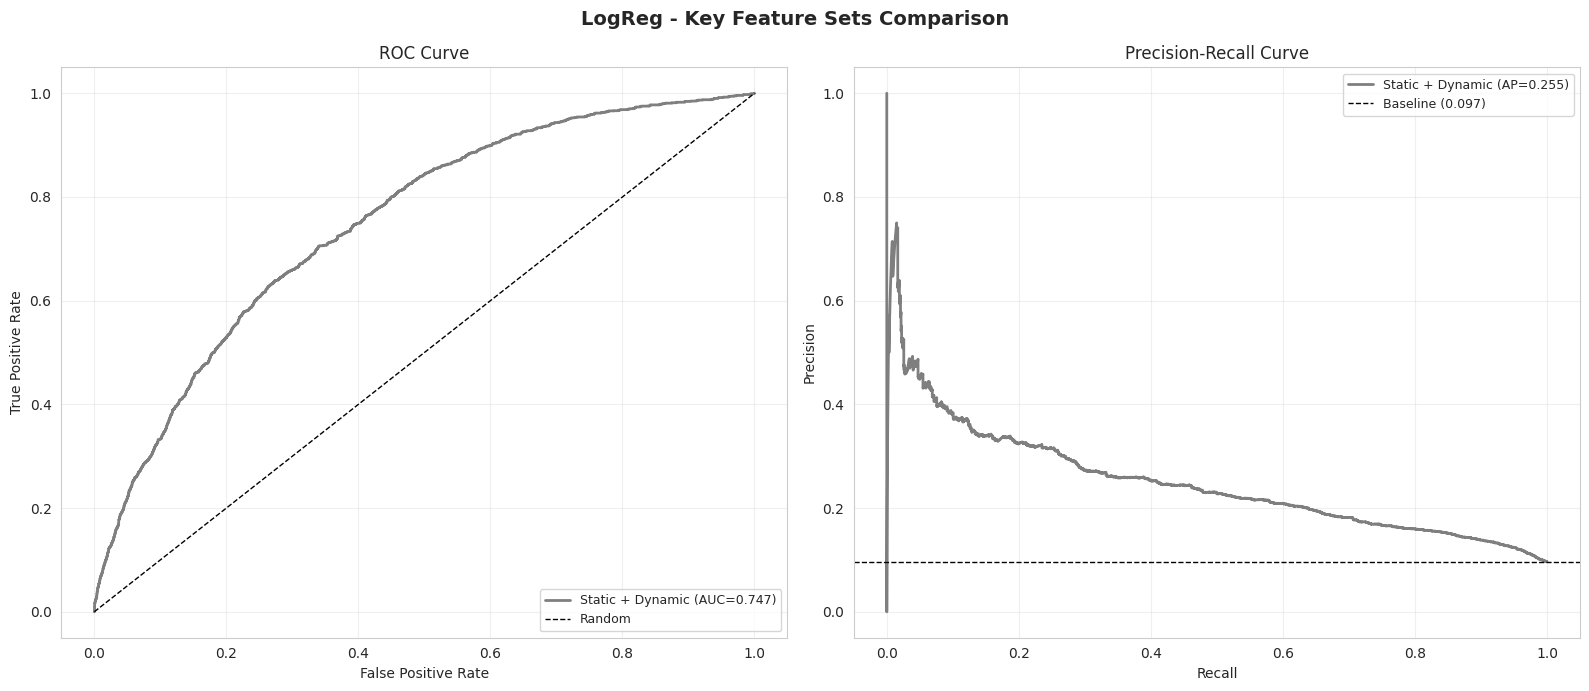

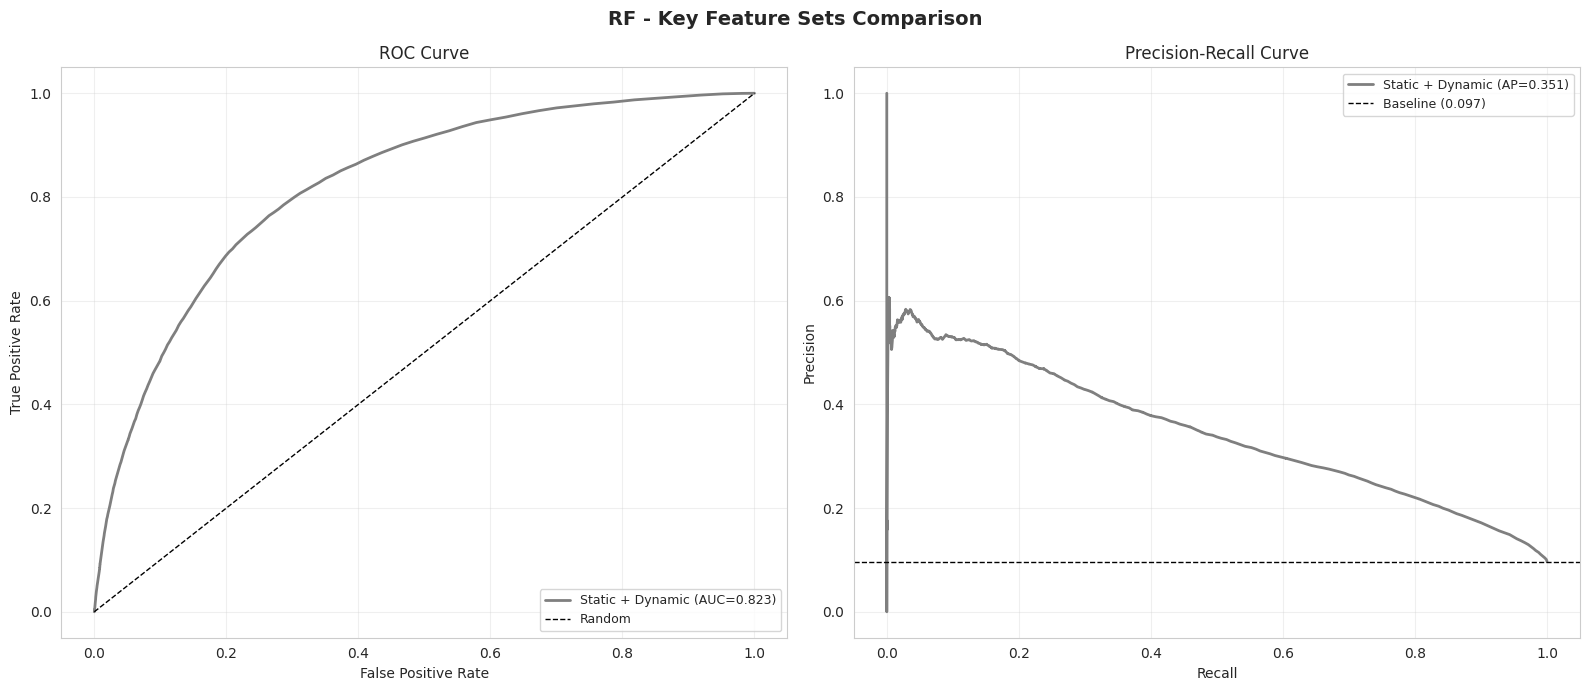

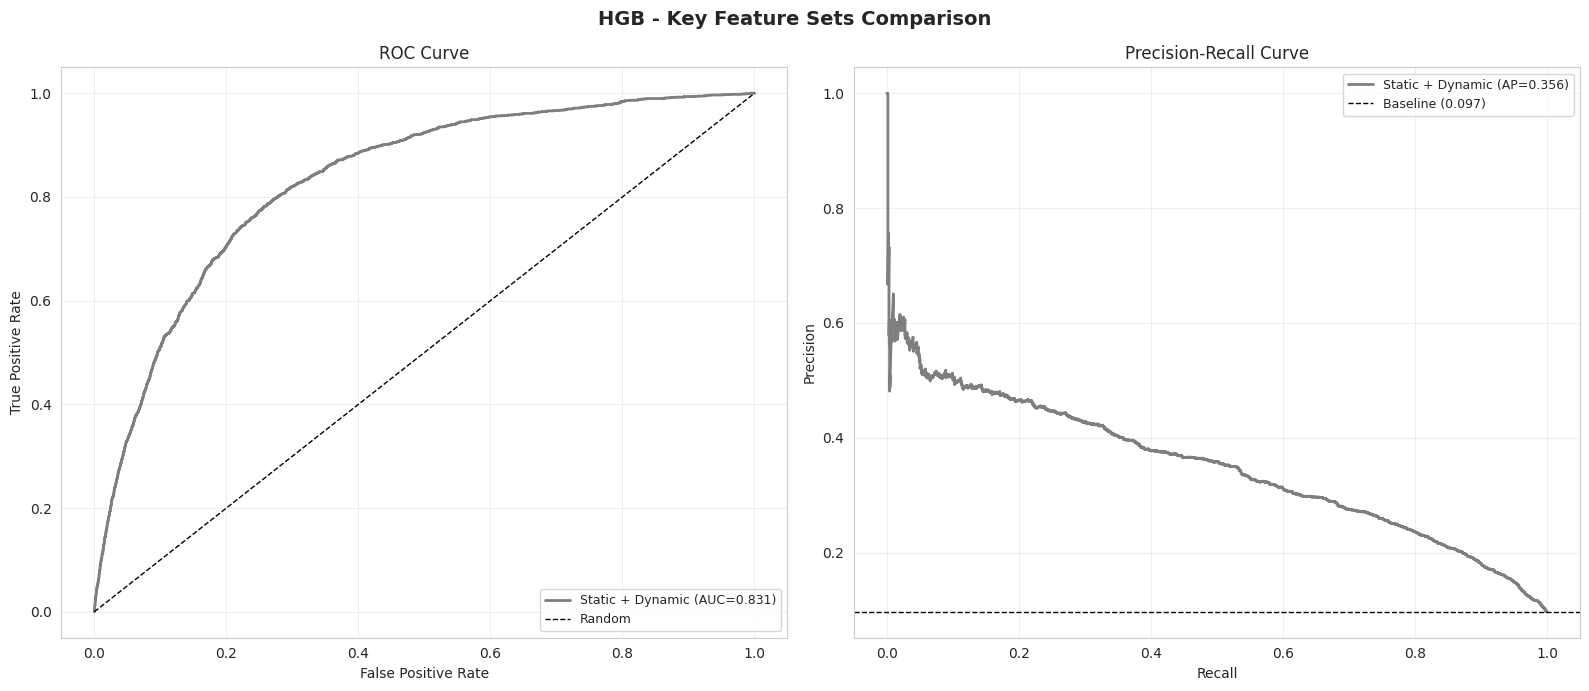

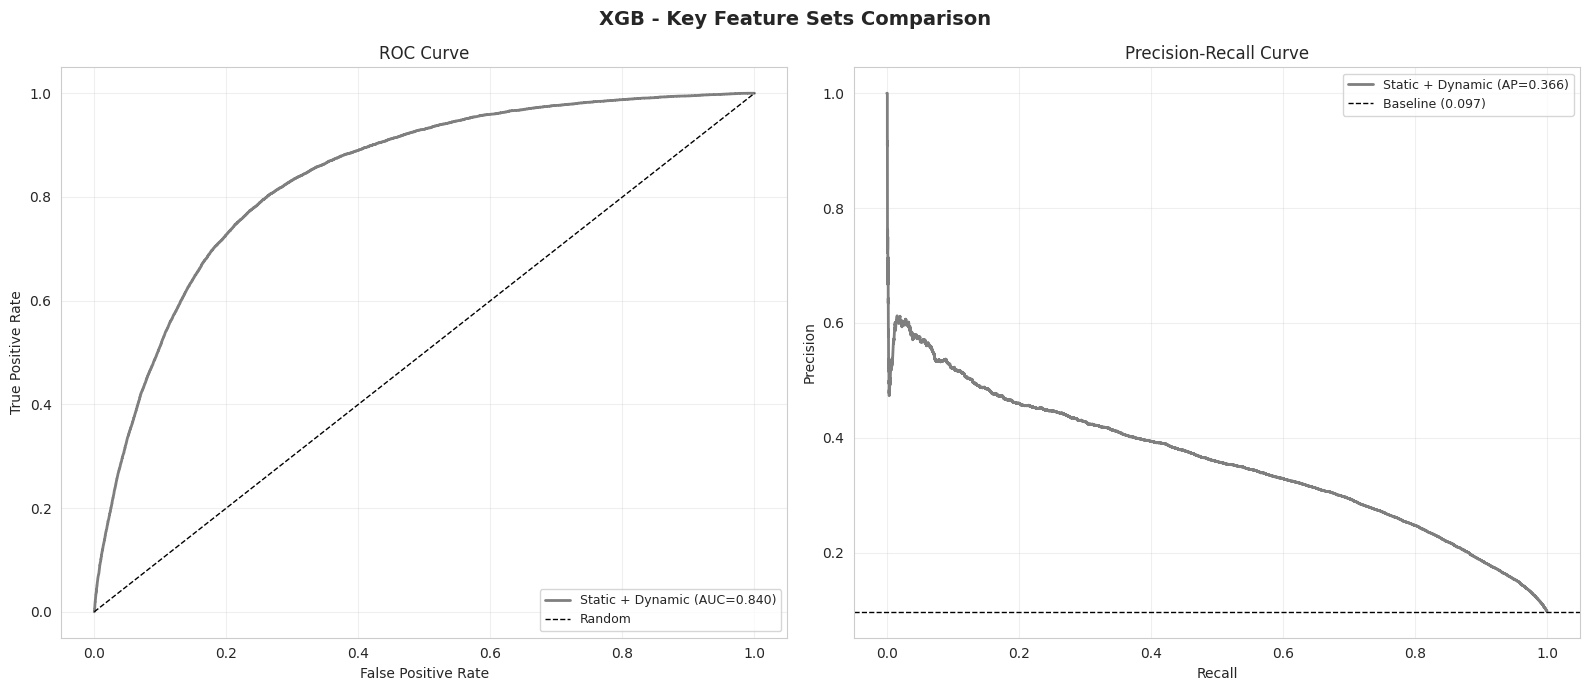

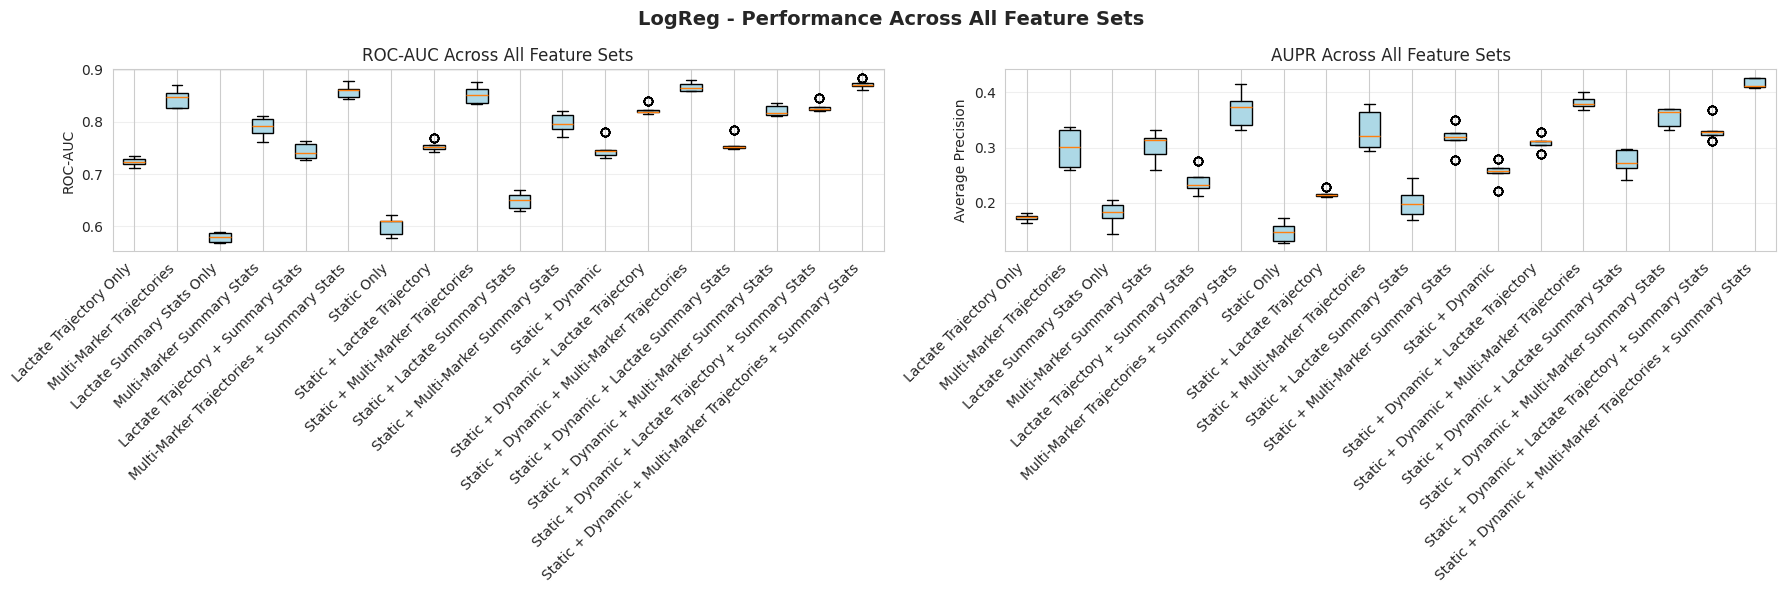

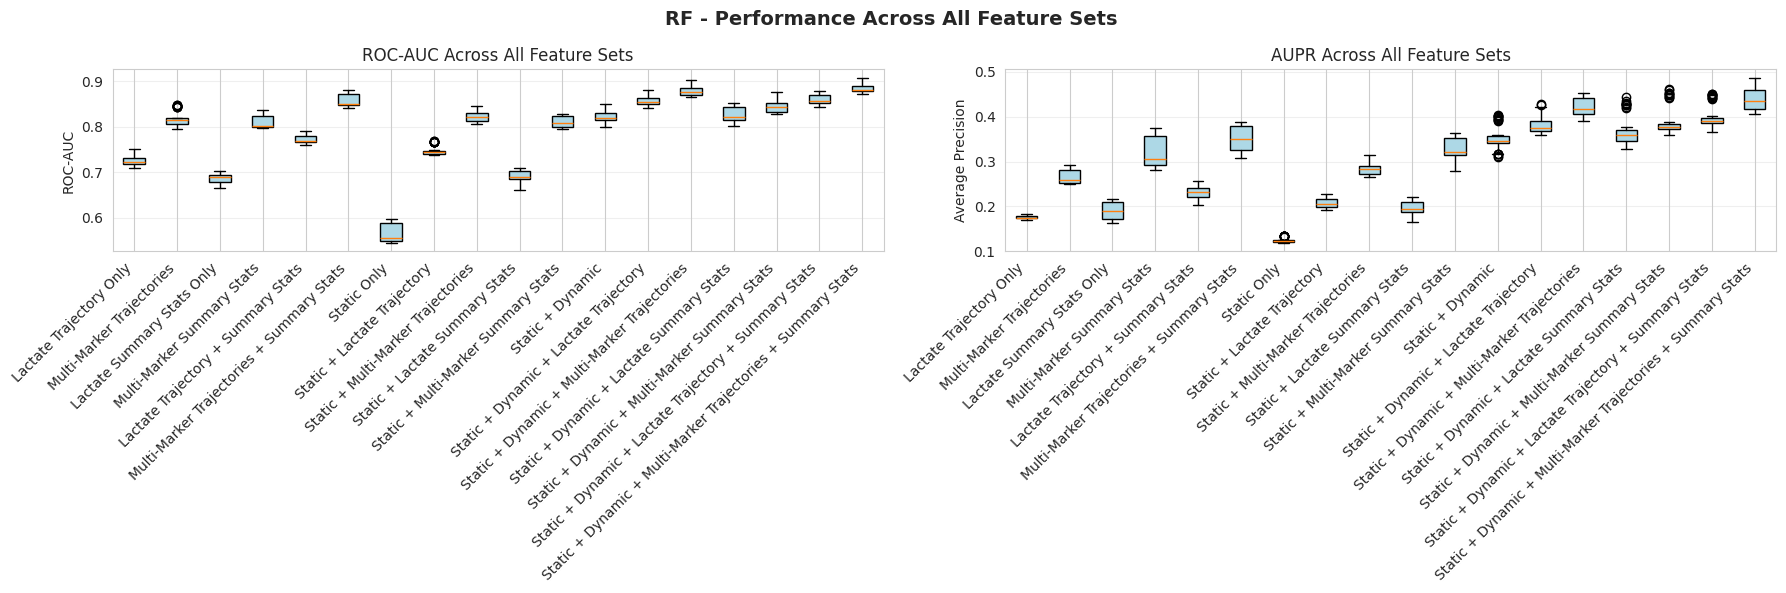

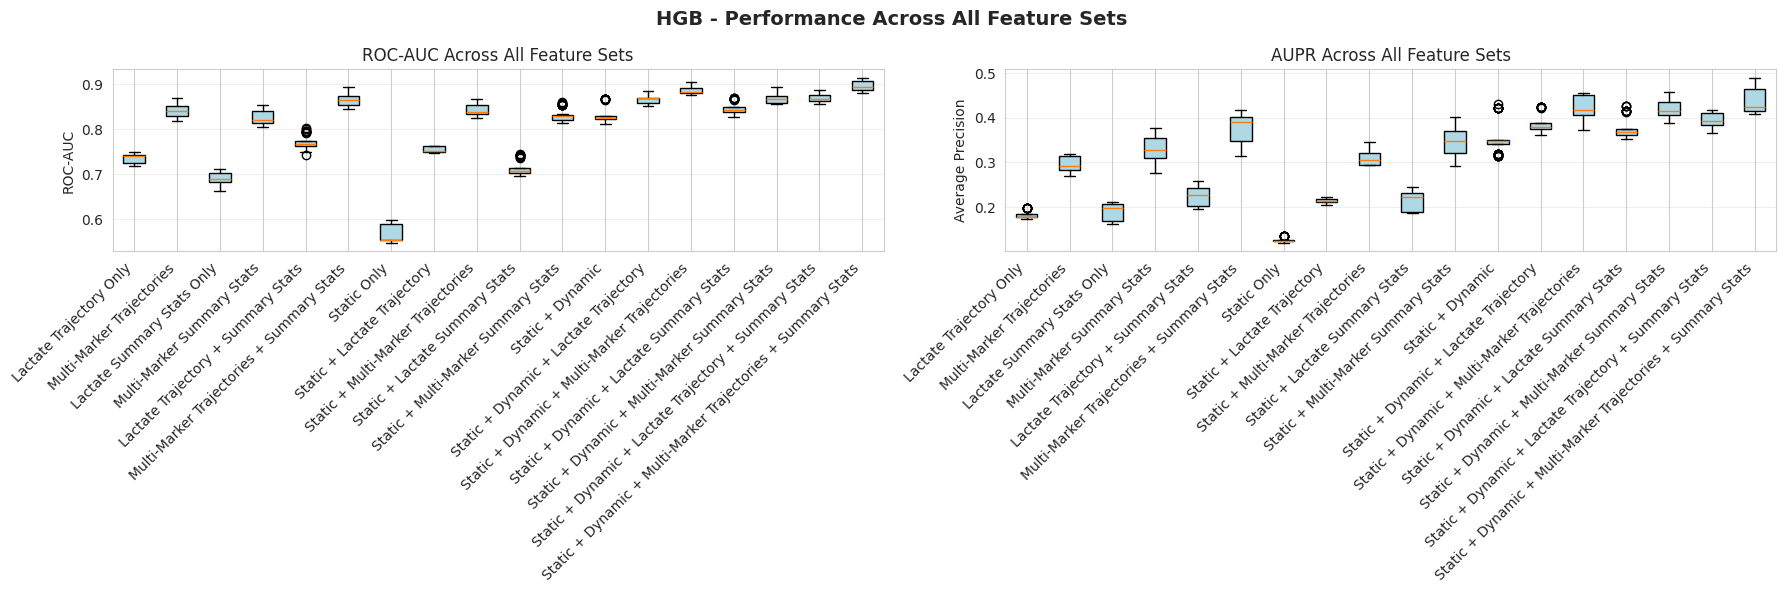

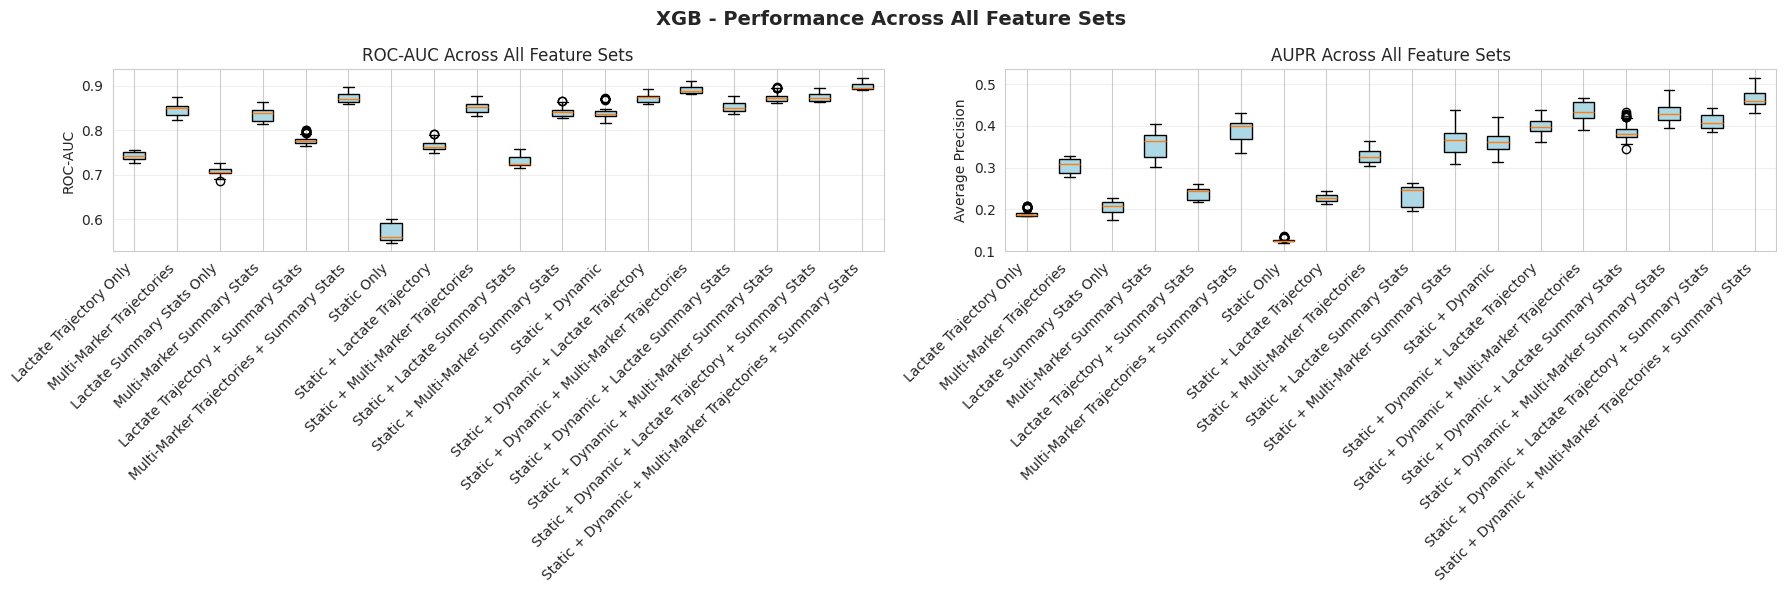

<Figure size 1200x500 with 0 Axes>

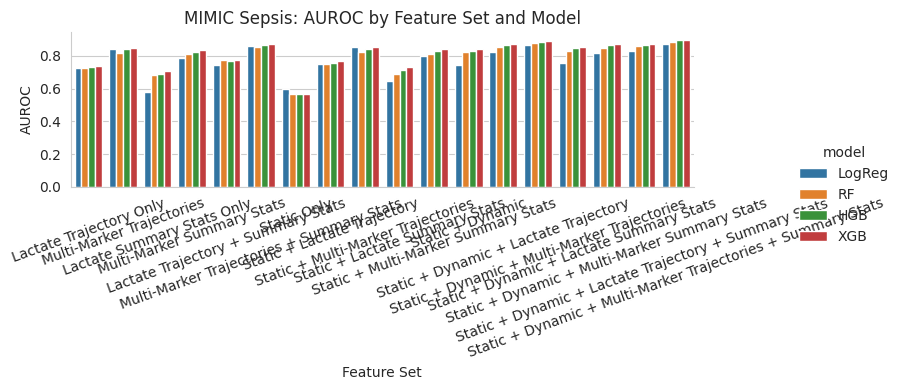

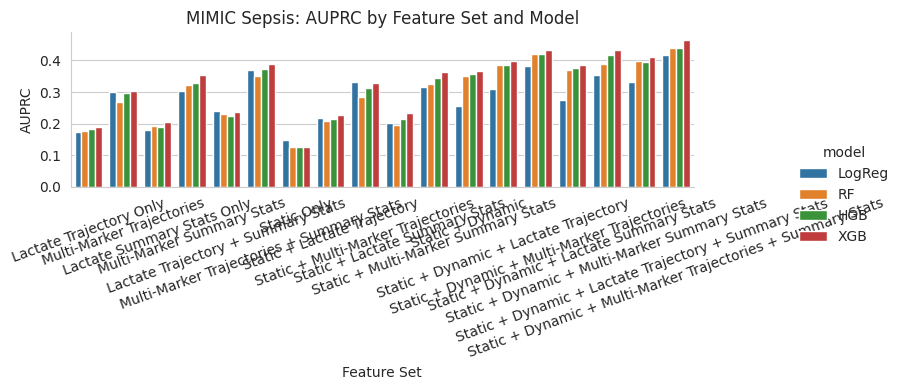

In [7]:
# ROC and PR curves for each model (key feature sets)
for model_name in results.keys():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f'{model_name} - Key Feature Sets Comparison', fontsize=14, fontweight='bold')

    key_sets = [
        'Trajectory Only',
        'Summary Stats Only',
        'Trajectory + Summary Stats',
        'Static + Dynamic',
        'Trajectory + Summary Stats + Static + Dynamic'
    ]

    colors = plt.cm.tab10(np.linspace(0, 1, len(key_sets)))

    for idx, name in enumerate(key_sets):
        if name not in results[model_name]:
            continue
        metrics = results[model_name][name]
        fpr, tpr, _ = roc_curve(metrics['y_true'], metrics['y_pred'])
        auc = np.mean(metrics['roc_auc'])
        ax1.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=colors[idx], linewidth=2)

        precision, recall, _ = precision_recall_curve(metrics['y_true'], metrics['y_pred'])
        ap = np.mean(metrics['avg_precision'])
        ax2.plot(recall, precision, label=f'{name} (AP={ap:.3f})', color=colors[idx], linewidth=2)

    ax1.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('ROC Curve')
    ax1.legend(loc='lower right', fontsize=9)
    ax1.grid(True, alpha=0.3)

    baseline = y.mean()
    ax2.axhline(y=baseline, color='k', linestyle='--', label=f'Baseline ({baseline:.3f})', linewidth=1)
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title('Precision-Recall Curve')
    ax2.legend(loc='upper right', fontsize=9)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Model Comparison Summary (boxplots)
for model_name in results.keys():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(f'{model_name} - Performance Across All Feature Sets', fontsize=14, fontweight='bold')

    feature_set_names = list(results[model_name].keys())
    roc_data = [results[model_name][name]['roc_auc'] for name in feature_set_names]
    ap_data = [results[model_name][name]['avg_precision'] for name in feature_set_names]

    bp1 = ax1.boxplot(roc_data, labels=feature_set_names, patch_artist=True)
    ax1.set_ylabel('ROC-AUC')
    ax1.set_title('ROC-AUC Across All Feature Sets')
    ax1.set_xticklabels(feature_set_names, rotation=45, ha='right')
    ax1.grid(alpha=0.3, axis='y')

    bp2 = ax2.boxplot(ap_data, labels=feature_set_names, patch_artist=True)
    ax2.set_ylabel('Average Precision')
    ax2.set_title('AUPR Across All Feature Sets')
    ax2.set_xticklabels(feature_set_names, rotation=45, ha='right')
    ax2.grid(alpha=0.3, axis='y')

    for bp in [bp1, bp2]:
        for patch in bp['boxes']:
            patch.set_facecolor('lightblue')

    plt.tight_layout()
    plt.show()

# Summary bar plots (AUROC/AUPRC means)
summary_plot_df = results_df.copy()
plt.figure(figsize=(12, 5))
sns.catplot(data=summary_plot_df, x='feature_set', y='auroc_mean', hue='model', kind='bar', height=4, aspect=2)
plt.title('MIMIC Sepsis: AUROC by Feature Set and Model')
plt.ylabel('AUROC')
plt.xlabel('Feature Set')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

sns.catplot(data=summary_plot_df, x='feature_set', y='auprc_mean', hue='model', kind='bar', height=4, aspect=2)
plt.title('MIMIC Sepsis: AUPRC by Feature Set and Model')
plt.ylabel('AUPRC')
plt.xlabel('Feature Set')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()